In [6]:
# Numerical Operations
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [8]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images:", X_train.shape)
print("Testing Images :", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4238s 25us/step
Training Images: (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


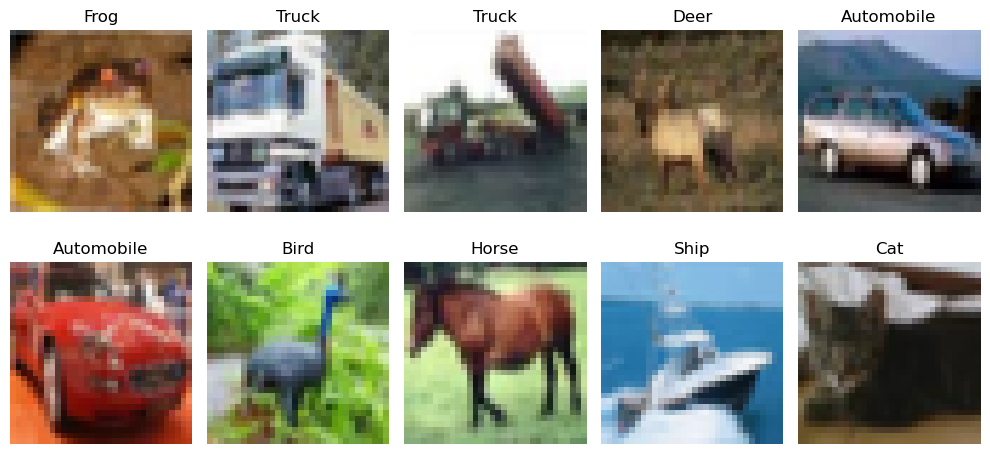

In [10]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

C:\Users\Jhanvi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4402 - loss: 1.5476 - val_accuracy: 0.5558 - val_loss: 1.2822
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5839 - loss: 1.1841 - val_accuracy: 0.5975 - val_loss: 1.1446
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6345 - loss: 1.0524 - val_accuracy: 0.6237 - val_loss: 1.0887
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6634 - loss: 0.9665 - val_accuracy: 0.6545 - val_loss: 1.0153
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.6884 - loss: 0.9015 - val_accuracy: 0.6650 - val_loss: 0.9770
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7094 - loss: 0.8419 - val_accuracy: 0.6749 - val_loss: 0.9394
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7286 - loss: 0.7892 - val_accuracy: 0.6806 - val_loss: 0.9397
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7407 - loss: 0.7448 - 

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6936 - loss: 0.9208
Test Accuracy: 69.36 %


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


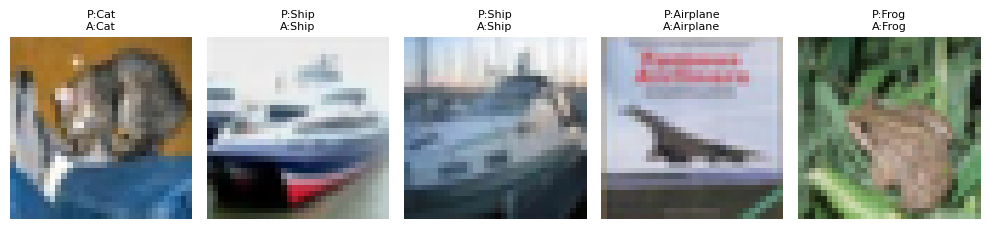

In [22]:
predictions = model.predict(X_test)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i])
    predicted = class_names[np.argmax(predictions[i])]
    actual = class_names[y_test[i][0]]

    plt.title(f"P:{predicted}\nA:{actual}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()